<a href="https://colab.research.google.com/github/z-serra/PythonNotes4ML/blob/main/ExamplesDataVisualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

df = pd.read_csv("https://raw.githubusercontent.com/sonalkapur/911-calls---Capstone-Project/refs/heads/master/911.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   lat        99492 non-null  float64
 1   lng        99492 non-null  float64
 2   desc       99492 non-null  object 
 3   zip        86637 non-null  float64
 4   title      99492 non-null  object 
 5   timeStamp  99492 non-null  object 
 6   twp        99449 non-null  object 
 7   addr       98973 non-null  object 
 8   e          99492 non-null  int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 6.8+ MB


In [2]:
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1


In [3]:
df["zip"].value_counts().head(5)

,count
zip,
19401.0,6979
19464.0,6643
19403.0,4854
19446.0,4748
19406.0,3174


In [4]:
df["twp"].value_counts().head(5)

,count
twp,
LOWER MERION,8443
ABINGTON,5977
NORRISTOWN,5890
UPPER MERION,5227
CHELTENHAM,4575


In [5]:
df["title"].nunique()

110

In [6]:
df["Reason"] = df["title"].apply(lambda title: title.split(':')[0])
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reason
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1,EMS
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1,EMS
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1,Fire
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1,EMS
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1,EMS


In [7]:
df["Reason"].value_counts().head(1)

,count
Reason,
EMS,48877


<Axes: xlabel='count', ylabel='Reason'>

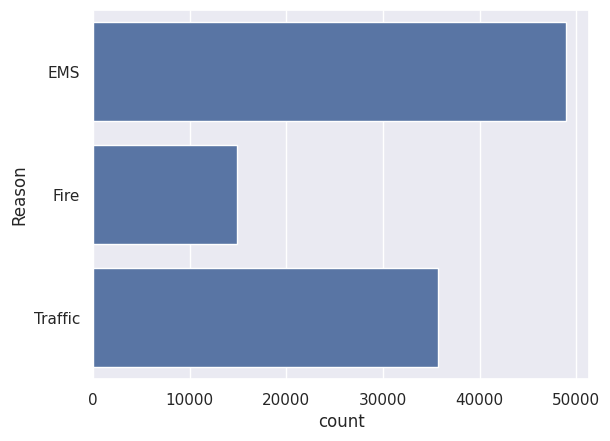

In [8]:
sns.countplot(df["Reason"])

In [9]:
type(df["timeStamp"][0])

str

In [10]:
df["timeStamp"] = pd.to_datetime(df["timeStamp"])
type(df["timeStamp"][0])

pandas._libs.tslibs.timestamps.Timestamp

In [11]:
df["Hour"] = df["timeStamp"].apply(lambda time: time.hour)
df["Month"] = df["timeStamp"].apply(lambda time: time.month)
df["Day Of Week"] = df["timeStamp"].apply(lambda time: time.day_of_week)
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reason,Hour,Month,Day Of Week
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1,EMS,17,12,3
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1,EMS,17,12,3
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1,Fire,17,12,3
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1,EMS,17,12,3
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1,EMS,17,12,3


In [12]:
dmap = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6:'Sun'}
df["Day Of Week"] = df["Day Of Week"].map(lambda x: dmap[x])
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reason,Hour,Month,Day Of Week
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1,EMS,17,12,Thu
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1,EMS,17,12,Thu
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1,Fire,17,12,Thu
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1,EMS,17,12,Thu
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1,EMS,17,12,Thu


<Axes: xlabel='Day Of Week', ylabel='count'>

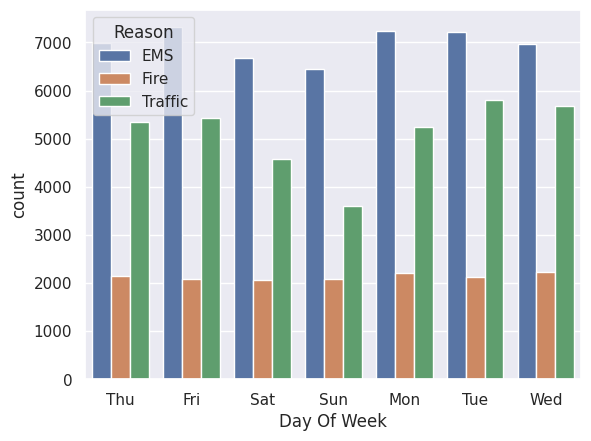

In [13]:
sns.countplot(data=df, x="Day Of Week", hue="Reason")

<Axes: xlabel='Month', ylabel='count'>

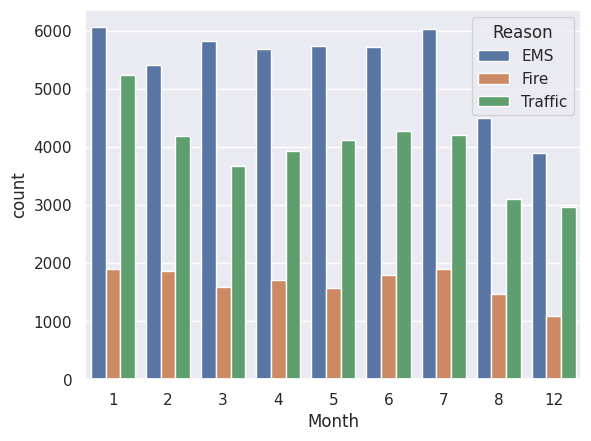

In [14]:
sns.countplot(data=df, x="Month", hue="Reason")

# where is 9 10 11

<Axes: xlabel='Month'>

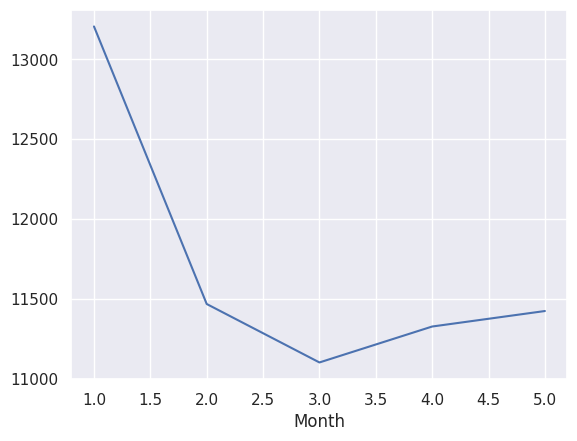

In [15]:
byMonth = df.groupby('Month').count().head()
byMonth["lat"].plot()

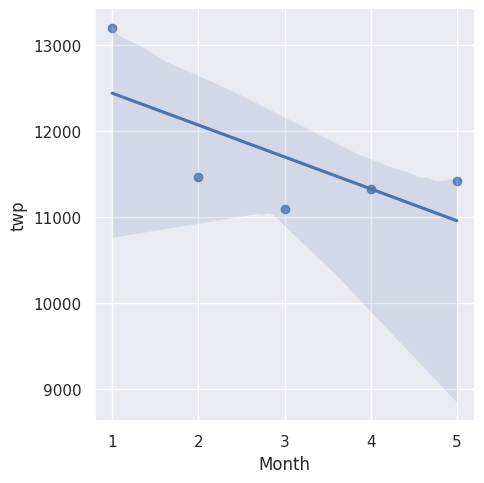

In [16]:
sns.lmplot(x="Month", y="twp", data=byMonth.reset_index())

In [17]:
df["Date"] = df["timeStamp"].apply(lambda x: x.date())
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reason,Hour,Month,Day Of Week,Date
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1,EMS,17,12,Thu,2015-12-10
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1,EMS,17,12,Thu,2015-12-10
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1,Fire,17,12,Thu,2015-12-10
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1,EMS,17,12,Thu,2015-12-10
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1,EMS,17,12,Thu,2015-12-10


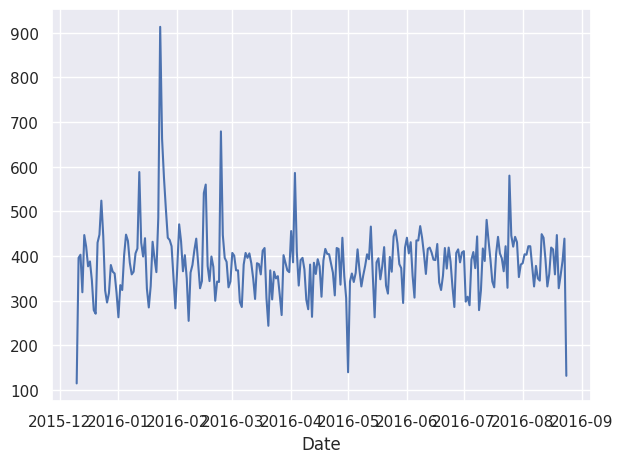

In [18]:
df.groupby("Date").count()["lat"].plot()
plt.tight_layout()

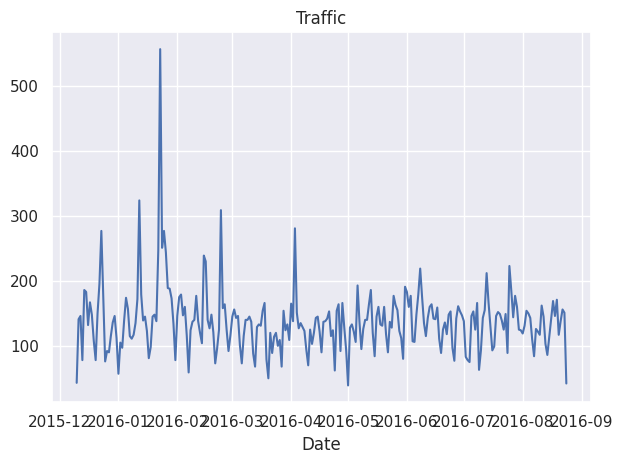

In [19]:
df[df['Reason']=="Traffic"].groupby("Date").count()["lat"].plot()
plt.title("Traffic")
plt.tight_layout()

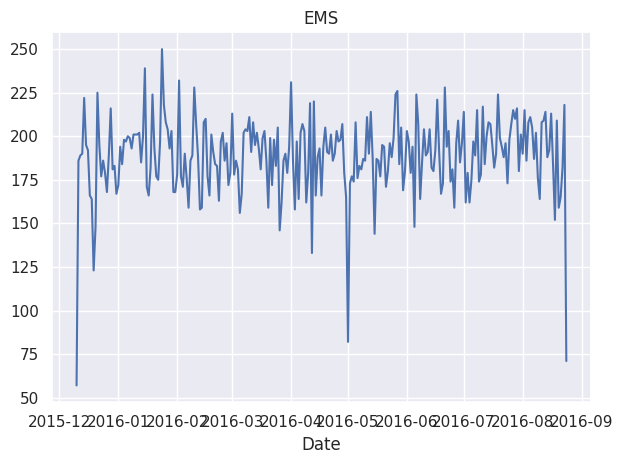

In [20]:
df[df['Reason']=="EMS"].groupby("Date").count()["lat"].plot()
plt.title("EMS")
plt.tight_layout()

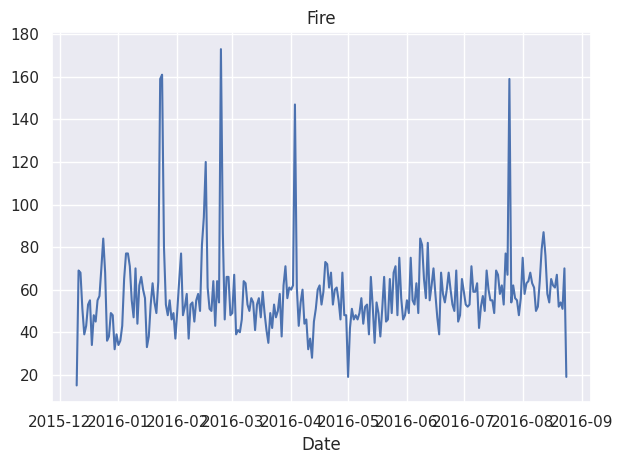

In [21]:
df[df['Reason']=="Fire"].groupby("Date").count()["lat"].plot()
plt.title("Fire")
plt.tight_layout()

In [22]:
df.groupby(by=["Day Of Week", "Hour"]).count().head()

lat  lng  desc  zip  title  timeStamp  twp  addr    e  \
Day Of Week Hour                                                          
Fri         0     275  275   275  248    275        275  275   275  275   
            1     235  235   235  200    235        235  235   232  235   
            2     191  191   191  165    191        191  191   191  191   
            3     175  175   175  164    175        175  175   175  175   
            4     201  201   201  184    201        201  201   201  201   

                  Reason  Month  Date  
Day Of Week Hour                       
Fri         0        275    275   275  
            1        235    235   235  
            2        191    191   191  
            3        175    175   175  
            4        201    201   201

In [23]:
dayHour = df.groupby(by=["Day Of Week", "Hour"]).count()["Reason"].unstack()
dayHour

Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Day Of Week,,,,,,,,,,,,,,,,,,,,,
Fri,275,235,191,175,201,194,372,598,742,752,...,932,980,1039,980,820,696,667,559,514,474
Mon,282,221,201,194,204,267,397,653,819,786,...,869,913,989,997,885,746,613,497,472,325
Sat,375,301,263,260,224,231,257,391,459,640,...,789,796,848,757,778,696,628,572,506,467
Sun,383,306,286,268,242,240,300,402,483,620,...,684,691,663,714,670,655,537,461,415,330
Thu,278,202,233,159,182,203,362,570,777,828,...,876,969,935,1013,810,698,617,553,424,354
Tue,269,240,186,170,209,239,415,655,889,880,...,943,938,1026,1019,905,731,647,571,462,274
Wed,250,216,189,209,156,255,410,701,875,808,...,904,867,990,1037,894,686,668,575,490,335


<Axes: xlabel='Hour', ylabel='Day Of Week'>

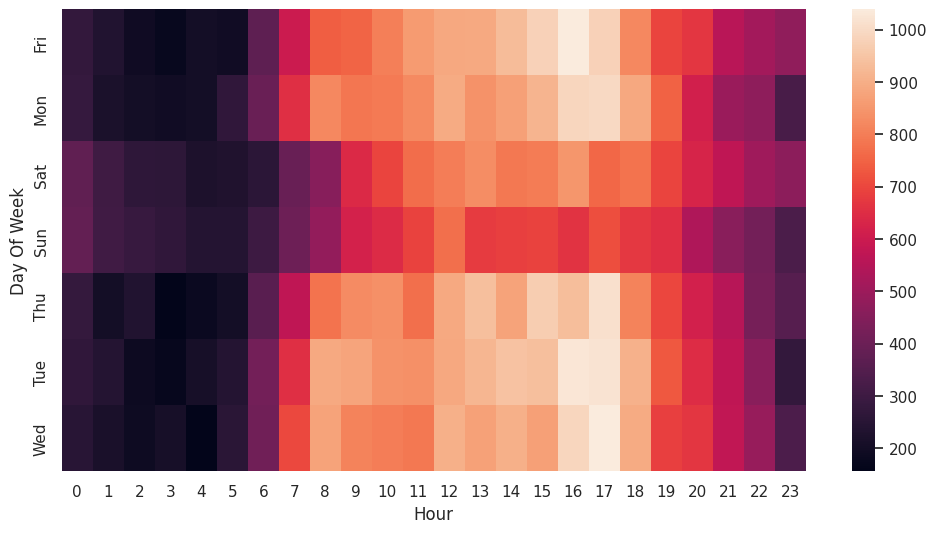

In [24]:
plt.figure(figsize=(12, 6))
sns.heatmap(dayHour)

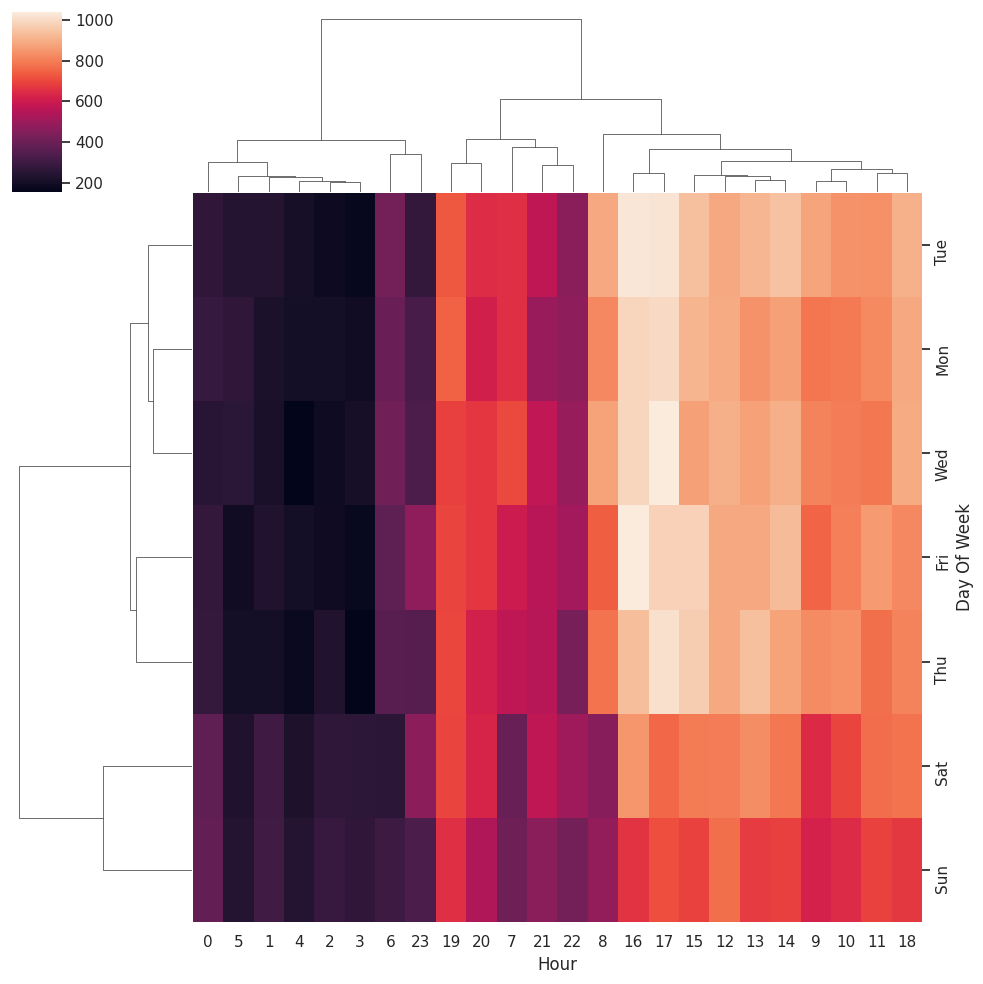

In [25]:
sns.clustermap(dayHour)

In [26]:
dayMonth = df.groupby(by=["Day Of Week", "Month"]).count()["Reason"].unstack()
dayMonth

Month,1,2,3,4,5,6,7,8,12
Day Of Week,,,,,,,,,
Fri,1970,1581,1525,1958,1730,1649,2045,1310,1065
Mon,1727,1964,1535,1598,1779,1617,1692,1511,1257
Sat,2291,1441,1266,1734,1444,1388,1695,1099,978
Sun,1960,1229,1102,1488,1424,1333,1672,1021,907
Thu,1584,1596,1900,1601,1590,2065,1646,1230,1266
Tue,1973,1753,1884,1430,1918,1676,1670,1612,1234
Wed,1700,1903,1889,1517,1538,2058,1717,1295,1262


<Axes: xlabel='Month', ylabel='Day Of Week'>

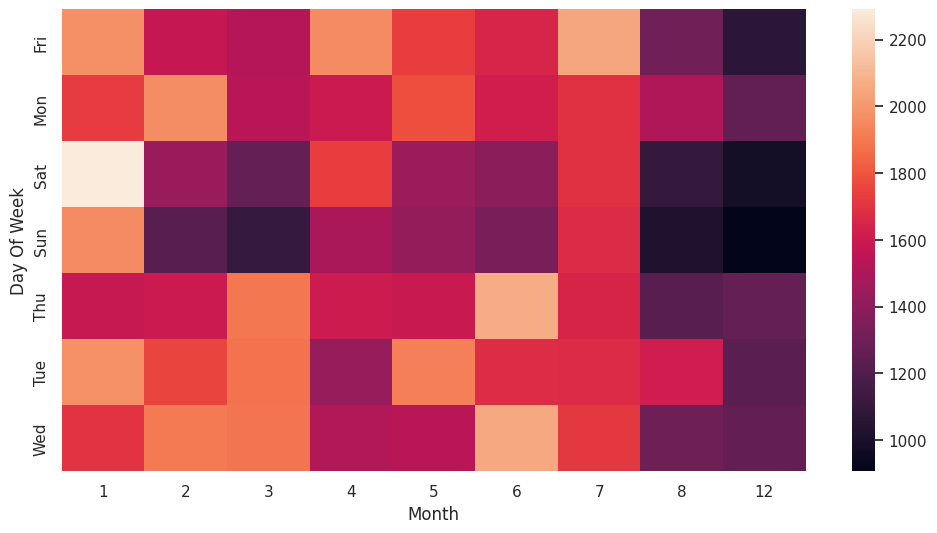

In [27]:
plt.figure(figsize=(12, 6))
sns.heatmap(dayMonth)

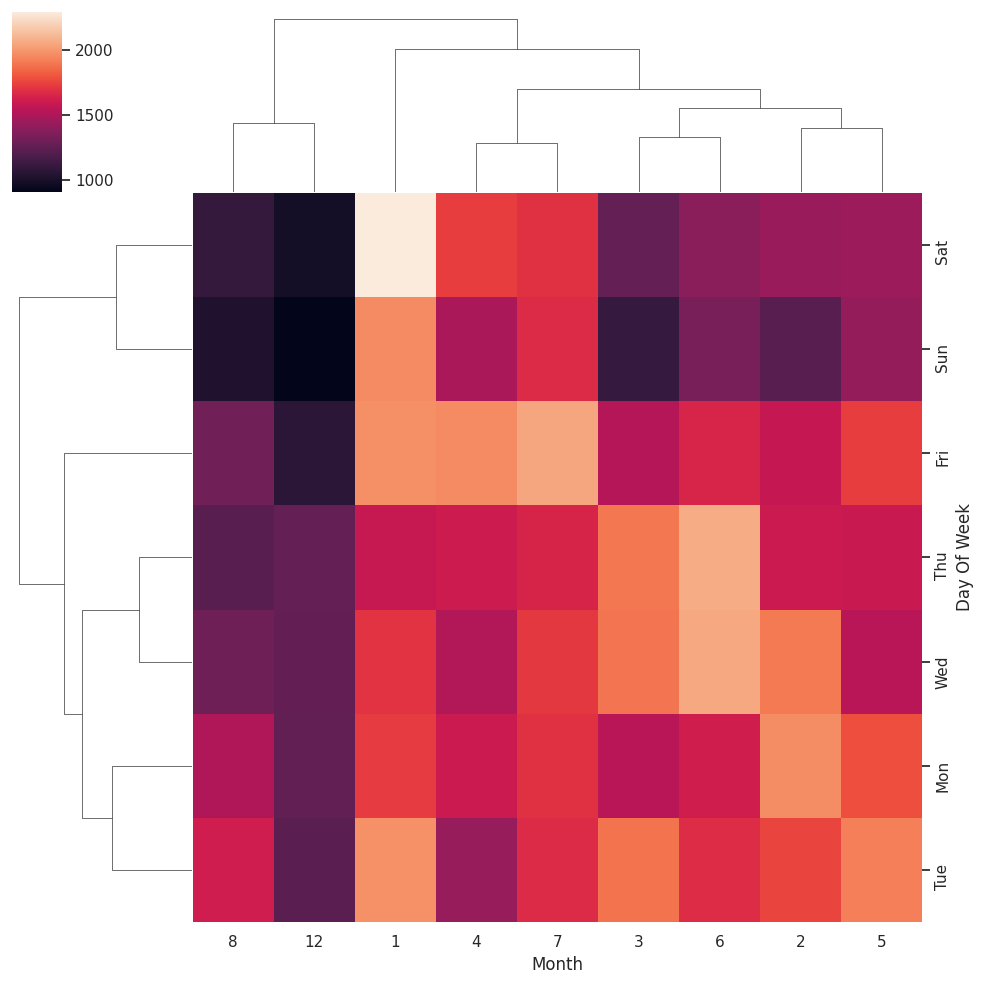

In [28]:
sns.clustermap(dayMonth)

In [29]:
import yfinance as yf

tickers = ["BAC", "C", "GS", "JPM", "MS", "WFC"]

df = yf.download(tickers, start="2006-01-01", end="2016-01-01")

df.columns.names = ['Stock Info', 'Bank Ticker']

df.head()

/tmp/ipykernel_27681/662447080.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start="2006-01-01", end="2016-01-01")
[*********************100%***********************]  6 of 6 completed


Stock Info       Close                                               \
Bank Ticker        BAC           C         GS        JPM         MS   
Date                                                                  
2006-01-03   30.487925  315.803406  93.358994  23.754633  31.349625   
2006-01-04   30.164145  309.973206  92.069496  23.617531  31.371134   
2006-01-05   30.202988  311.510925  92.033272  23.689060  31.457159   
2006-01-06   30.157646  311.510925  93.337303  23.855972  31.489403   
2006-01-09   30.177099  310.037354  94.460129  24.243435  31.822739   

Stock Info                   High                                    ...  \
Bank Ticker        WFC        BAC           C         GS        JPM  ...   
Date                                                                 ...   
2006-01-03   18.379143  30.552681  316.380036  93.771931  23.855114  ...   
2006-01-04   18.165966  30.591545  314.586291  93.387988  23.927504  ...   
2006-01-05   18.145809  30.326029  312.536038  92.236115  23.730787  ...   
2006-01-06   18.252392  30.377822  313.304892  93.634328  23.987115  ...   
2006-01-09   18.249502  30.416705  312.279823  94.626748  24.273242  ...   

Stock Info        Open                                     Volume           \
Bank Ticker         GS        JPM         MS        WFC       BAC        C   
Date                                                                         
2006-01-03   91.786953  23.541854  30.736717  18.206299  16296700  1537600   
2006-01-04   92.257853  23.712907  31.559308  18.321525  17757900  1870960   
2006-01-05   91.279850  23.611566  31.478665  18.148689  14970700  1143160   
2006-01-06   92.214419  23.796361  31.596931  18.194777  12599800  1370210   
2006-01-09   93.090932  23.772517  31.521663  18.249502  15619400  1680740   

Stock Info                                         
Bank Ticker       GS       JPM       MS       WFC  
Date                                               
2006-01-03   6188700  12838600  5377000  11016400  
2006-01-04   4861600  13491500  7977800  10870000  
2006-01-05   3717400   8109400  5778000  10158000  
2006-01-06   4319600   7966900  6889800   8403800  
2006-01-09   4723500  16575200  4144500   5619600  

[5 rows x 30 columns]

In [30]:
for tick in tickers:
  print(tick, df["Close"][tick].max())

BAC 36.87028503417969
C 376.5052490234375
GS 182.2994384765625
JPM 52.8502311706543
MS 49.1440315246582
WFC 43.32756042480469


In [31]:
df.xs(key='Close', axis=1, level="Stock Info").max()

,0
Bank Ticker,
BAC,36.870285
C,376.505249
GS,182.299438
JPM,52.850231
MS,49.144032
WFC,43.327560


In [32]:
returns = pd.DataFrame()
for tick in tickers:
  returns[tick + " Return"] = df['Close'][tick].pct_change()
returns.head()

,BAC Return,C Return,GS Return,JPM Return,MS Return,WFC Return
Date,,,,,,
2006-01-03,NaN,NaN,NaN,NaN,NaN,NaN
2006-01-04,-0.010620,-0.018461,-0.013812,-0.005772,0.000686,-0.011599
2006-01-05,0.001288,0.004961,-0.000393,0.003029,0.002742,-0.001110
2006-01-06,-0.001501,0.000000,0.014169,0.007046,0.001025,0.005874
2006-01-09,0.000645,-0.004730,0.012030,0.016242,0.010586,-0.000158


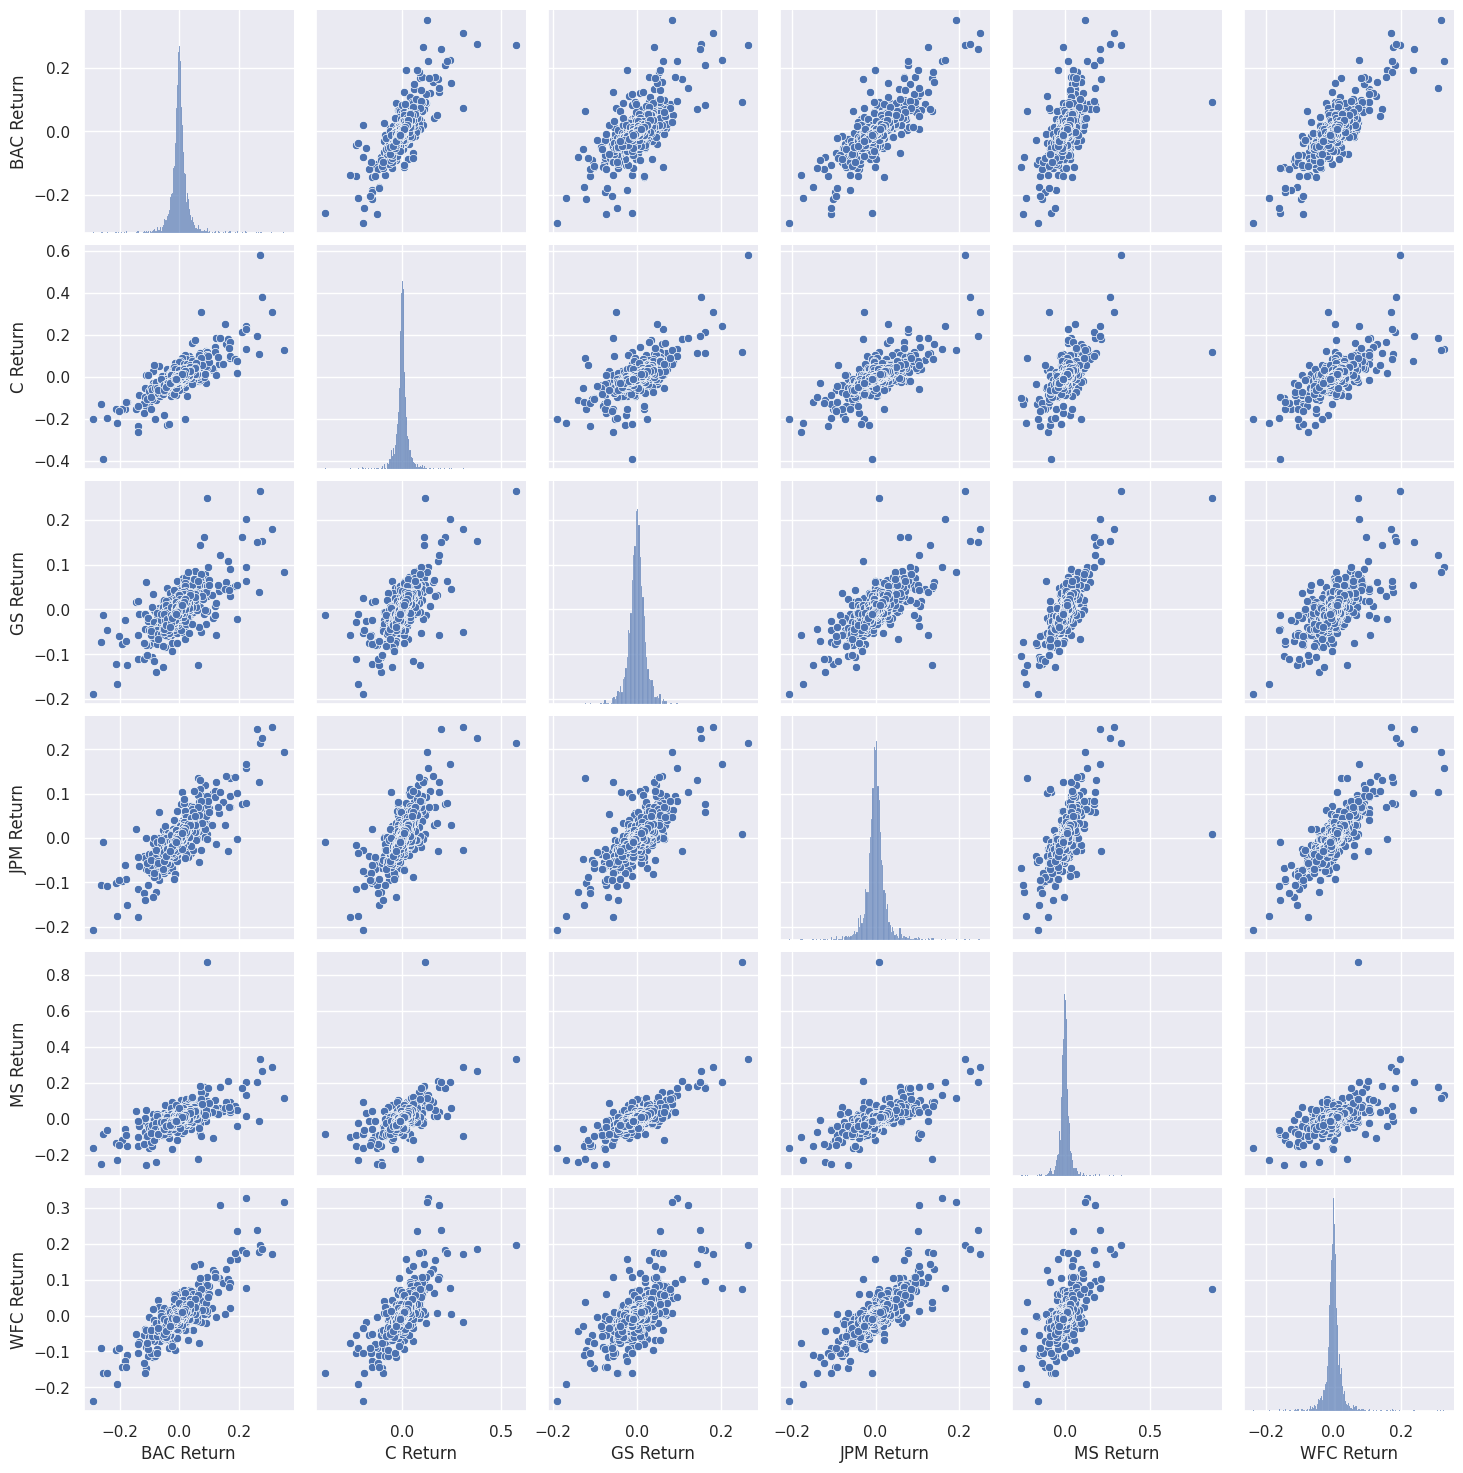

In [33]:
sns.pairplot(returns[1:])

In [34]:
returns.idxmin()

,0
BAC Return,2009-01-20
C Return,2009-02-27
GS Return,2009-01-20
JPM Return,2009-01-20
MS Return,2008-10-09
WFC Return,2009-01-20


In [35]:
returns.idxmax()

,0
BAC Return,2009-04-09
C Return,2008-11-24
GS Return,2008-11-24
JPM Return,2009-01-21
MS Return,2008-10-13
WFC Return,2008-07-16


In [36]:
returns.std()

,0
BAC Return,0.036659
C Return,0.038672
GS Return,0.025386
JPM Return,0.027675
MS Return,0.037717
WFC Return,0.030195


In [37]:
returns.loc['2015-01-01':'2015-12-31'].std()

,0
BAC Return,0.016174
C Return,0.015288
GS Return,0.014043
JPM Return,0.014006
MS Return,0.016287
WFC Return,0.012552


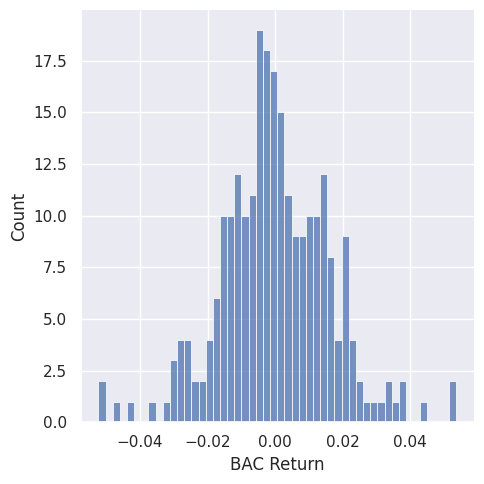

In [38]:
sns.displot(returns.loc['2015-01-01':'2015-12-31']['BAC Return'], bins=50)

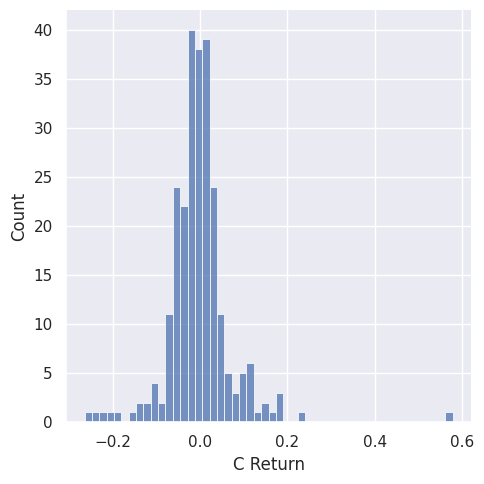

In [39]:
sns.displot(returns.loc['2008-01-01':'2008-12-31']['C Return'], bins=50)

<Axes: xlabel='Date'>

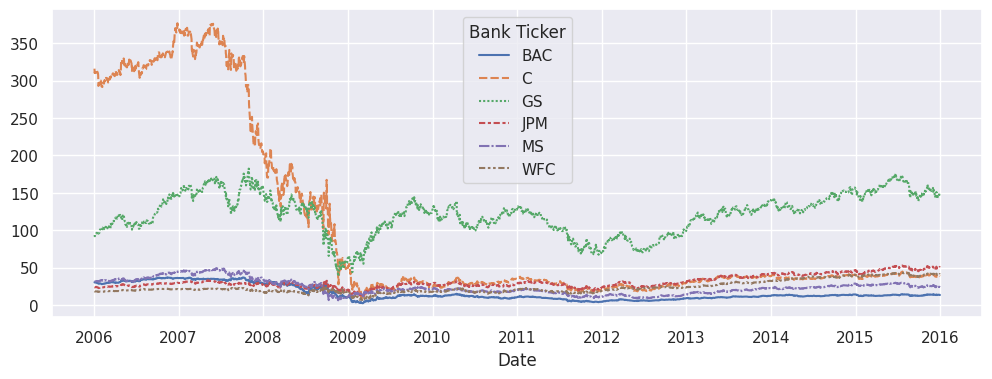

In [40]:
plt.figure(figsize=(12, 4))
sns.lineplot(df.xs(key='Close', axis=1, level="Stock Info"))

In [41]:
import plotly.express as px
px.line(df.xs(key='Close', axis=1, level="Stock Info"))

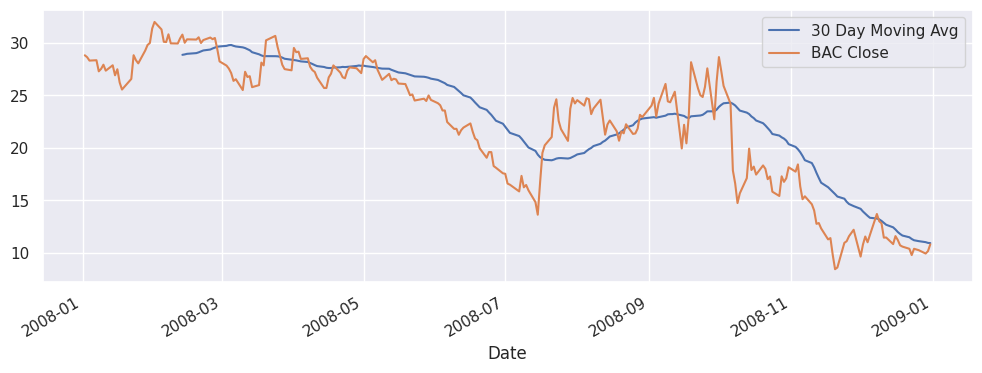

In [42]:
plt.figure(figsize=(12, 4))
df['Close']['BAC'].loc['2008-01-01':'2008-12-31'].rolling(window=30).mean().plot(label="30 Day Moving Avg")
df['Close']['BAC'].loc['2008-01-01':'2008-12-31'].plot(label="BAC Close")
plt.legend()

<Axes: xlabel='Bank Ticker', ylabel='Bank Ticker'>

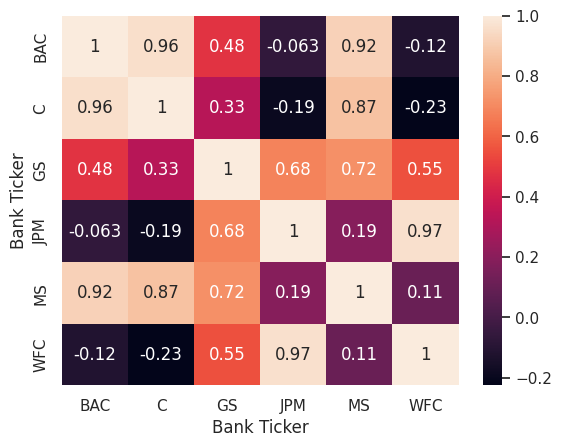

In [43]:
sns.heatmap(df.xs(key='Close', axis=1, level="Stock Info").corr(), annot=True)

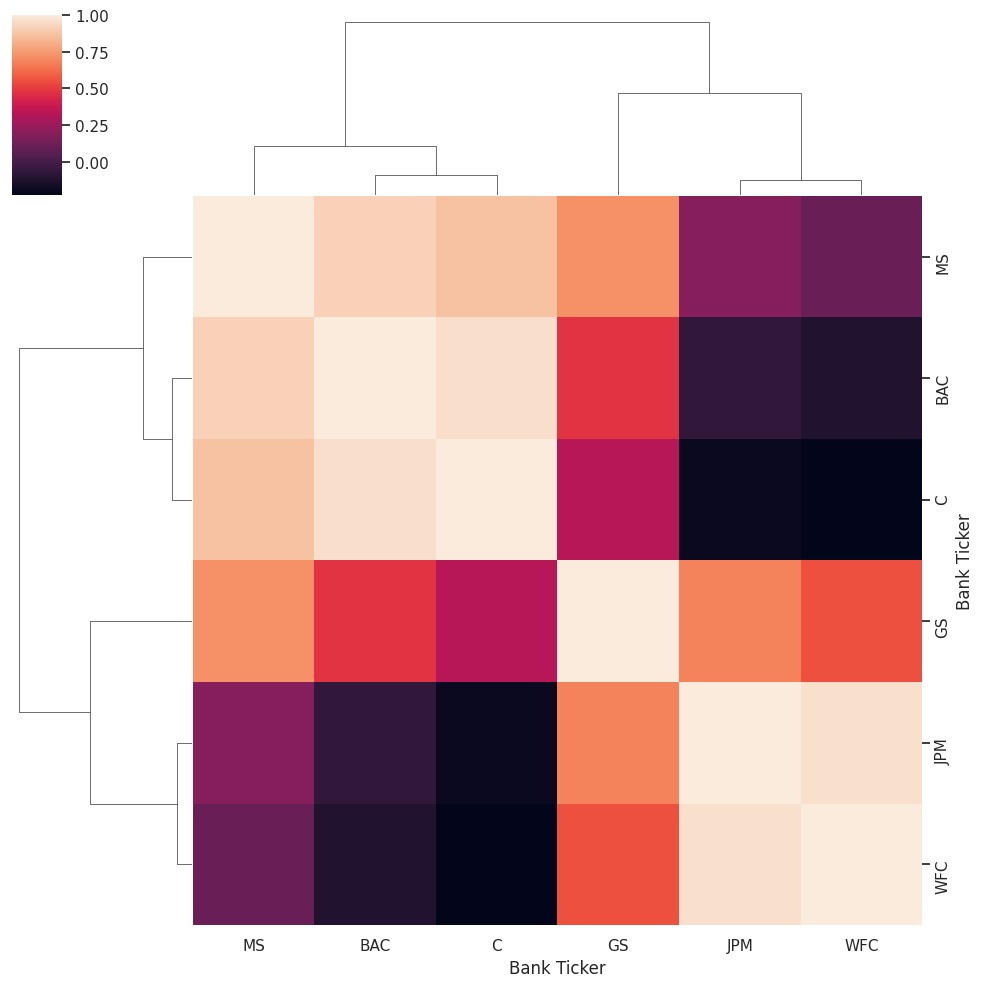

In [44]:
sns.clustermap(df.xs(key='Close', axis=1, level="Stock Info").corr())

In [45]:
close_corr = df.xs(key='Close', axis=1, level="Stock Info").corr()

In [46]:
px.imshow(close_corr, color_continuous_scale="RdYlBu")

In [47]:
import plotly.graph_objects as go

go.Figure(data=[go.Candlestick(
    x=df.loc['2015'].index,
    open=df.loc['2015']['Open']['BAC'],
    high=df.loc['2015']['High']['BAC'],
    low=df.loc['2015']['Low']['BAC'],
    close=df.loc['2015']['Close']['BAC']
)]).show()

In [48]:
ms = df['Close']['MS'].loc['2015-01-01':'2015-12-31']

fig = go.Figure()

fig.add_trace(go.Scatter(x=ms.index, y=ms, name="Close"))
fig.add_trace(go.Scatter(x=ms.index, y=ms.rolling(13).mean(), name="SMA 13"))
fig.add_trace(go.Scatter(x=ms.index, y=ms.rolling(21).mean(), name="SMA 21"))
fig.add_trace(go.Scatter(x=ms.index, y=ms.rolling(55).mean(), name="SMA 55"))

In [49]:
ms = df['Close']['BAC'].loc['2015-01-01':'2015-12-31']

mean = ms.rolling(20).mean()
std = ms.rolling(20).std()

upper = mean + 2*std
lower = mean - 2*std

fig = go.Figure()

fig.add_trace(go.Scatter(x=ms.index, y=ms, name="Close"))
fig.add_trace(go.Scatter(x=ms.index, y=mean, name="Middle (SMA 20)"))
fig.add_trace(go.Scatter(x=ms.index, y=upper, name="Upper Band"))
fig.add_trace(go.Scatter(x=ms.index, y=lower, name="Lower Band"))